# RANSAC Regression for Outlier Detection

This notebook demonstrates how to use the RANSAC (Random Sample Consensus) algorithm for robust linear regression, specifically for identifying and handling outliers in a dataset.

**Steps:**

1.  **Load Data:** Load the Boston housing dataset.
2.  **Extract Features:** Select the 'LSTAT' (% lower status population) as the feature and 'MEDV' (median home value) as the target variable.
3.  **Apply Standard Linear Regression:** Train a standard `LinearRegression` model on the data.
4.  **Apply RANSAC Regression:** Train a `RANSACRegressor` model on the data. RANSAC iteratively fits models to random subsets of the data and identifies inliers (data points that fit the model well) and outliers (data points that do not fit the model well).
5.  **Visualize Results:** Plot the data points, highlighting the detected outliers. Compare the regression lines from the standard linear regression and the RANSAC models.
6.  **Summarize Findings:** Report the number of detected outliers and the equations of the fitted lines from both models, demonstrating RANSAC's robustness to outliers.

#### **DATASET Description**: The dataset used is the Boston housing dataset, which contains information about various features of houses in Boston suburbs and their corresponding median home values. We will focus on the relationship between the percentage of lower status population ('LSTAT') and the median home value ('MEDV').

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd


In [ ]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

In [ ]:
data

array([[6.3200e-03, 1.8000e+01, 2.3100e+00, ..., 1.5300e+01, 3.9690e+02,
        4.9800e+00],
       [2.7310e-02, 0.0000e+00, 7.0700e+00, ..., 1.7800e+01, 3.9690e+02,
        9.1400e+00],
       [2.7290e-02, 0.0000e+00, 7.0700e+00, ..., 1.7800e+01, 3.9283e+02,
        4.0300e+00],
       ...,
       [6.0760e-02, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9690e+02,
        5.6400e+00],
       [1.0959e-01, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9345e+02,
        6.4800e+00],
       [4.7410e-02, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9690e+02,
        7.8800e+00]])

In [ ]:
# Extract LSTAT and MEDV
X = data[:, 12].reshape(-1, 1)  # LSTAT: % lower status population
y = target                       # MEDV: Median home value


In [ ]:
print(f"Dataset: {len(X)} samples")
print(f"Feature: LSTAT (% lower status)")
print(f"Target: MEDV (home value in $1000s)")

Dataset: 506 samples
Feature: LSTAT (% lower status)
Target: MEDV (home value in $1000s)


#### **LSTAT**:  “% Lower Status of the Population”

What it represents: The percentage of people in a town or neighborhood who are considered lower socio-economic status.

Type: Feature (independent variable, X)

Why it matters: Higher LSTAT values usually indicate poorer neighborhoods, which often correlates with lower home values (MEDV).

#### **MEDV**: “Median value of owner-occupied homes”

What it represents: The median price of houses in a neighborhood, measured in $1000s.

Type: Target (dependent variable, y)

Why it matters: This is the variable we want to predict using features like LSTAT, RM (average rooms), etc.

In [ ]:
lr = LinearRegression()
lr.fit(X, y)

# RANSAC
ransac = RANSACRegressor(random_state=42)
ransac.fit(X, y)

# Get outlier mask
inlier_mask = ransac.inlier_mask_
outlier_mask = ~inlier_mask

print(f"\nInliers: {inlier_mask.sum()}")
print(f"Outliers: {outlier_mask.sum()}")


Inliers: 312
Outliers: 194


### What is RANSACRegressor and how it actually works?

1. What It Does

- Standard regression (like Linear Regression) can be heavily influenced by outliers.

- RANSAC is designed to ignore outliers and focus only on the "inliers" that fit the general trend.

2. How It Works (Step-by-Step)

- Random Sampling:

  - Randomly select a small subset of the data points.

- Fit Base Model:

  - Fit a model (usually Linear Regression) on this subset.

- Find Inliers:

  - Check which data points in the whole dataset are close enough to this model (within some threshold).

  - These points are called inliers.

- Repeat:

  - Repeat the random sampling and fitting multiple times.

- Select Best Model:

  - Choose the model with the largest number of inliers.

  - Refit the base model using all these inliers.

### Why do we need Linear Regression if we already have RANSACregressor?

RANSAC (RANdom SAmple Consensus) is not a regression model on its own.

It’s a robust estimator technique. Its main job is to fit a model while ignoring outliers.

Essentially, RANSAC repeatedly selects random subsets of data, fits a model (usually linear regression) to that subset, and checks which data points are inliers (close enough to the model).

The final model is the one that has the most inliers.

Key point: RANSAC needs a base model to fit — commonly, this is linear regression.

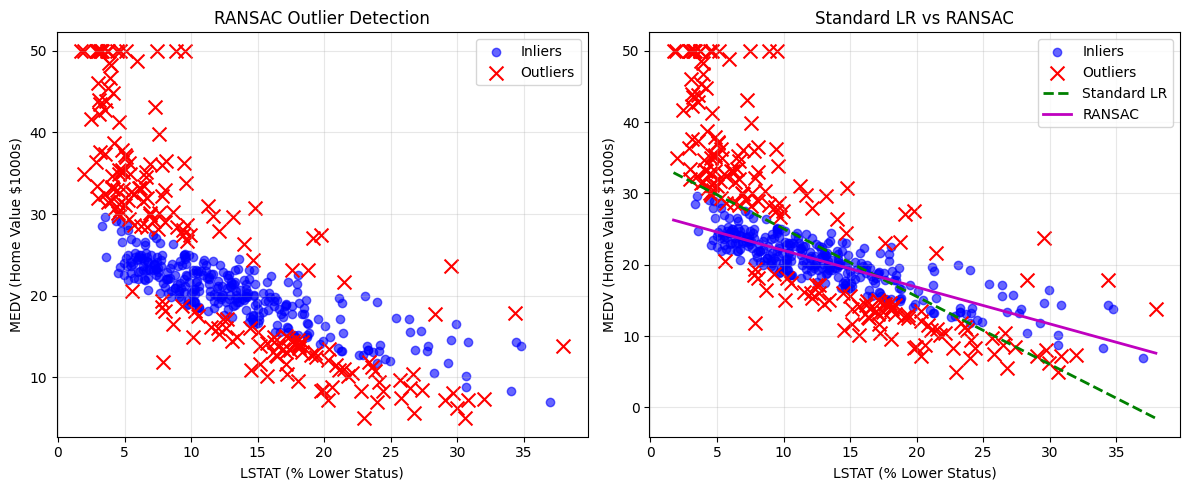

Total samples: 506
Outliers detected: 194 (38.3%)

Standard LR: y = -0.95x + 34.55
RANSAC: y = -0.51x + 27.16

RANSAC is robust to outliers and finds the true trend!


In [ ]:
plt.figure(figsize=(12, 5))

# Plot 1: Detected Outliers
plt.subplot(1, 2, 1)
plt.scatter(X[inlier_mask], y[inlier_mask], c='blue', label='Inliers', alpha=0.6)
plt.scatter(X[outlier_mask], y[outlier_mask], c='red', label='Outliers', marker='x', s=100)
plt.xlabel('LSTAT (% Lower Status)')
plt.ylabel('MEDV (Home Value $1000s)')
plt.title('RANSAC Outlier Detection')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Model Comparison
plt.subplot(1, 2, 2)
plt.scatter(X[inlier_mask], y[inlier_mask], c='blue', alpha=0.6, label='Inliers')
plt.scatter(X[outlier_mask], y[outlier_mask], c='red', marker='x', s=100, label='Outliers')

# Plot regression lines
X_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
plt.plot(X_line, lr.predict(X_line), 'g--', linewidth=2, label='Standard LR')
plt.plot(X_line, ransac.predict(X_line), 'm-', linewidth=2, label='RANSAC')

plt.xlabel('LSTAT (% Lower Status)')
plt.ylabel('MEDV (Home Value $1000s)')
plt.title('Standard LR vs RANSAC')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ## 4. Summary

print(f"Total samples: {len(X)}")
print(f"Outliers detected: {outlier_mask.sum()} ({outlier_mask.sum()/len(X)*100:.1f}%)")
print(f"\nStandard LR: y = {lr.coef_[0]:.2f}x + {lr.intercept_:.2f}")
print(f"RANSAC: y = {ransac.estimator_.coef_[0]:.2f}x + {ransac.estimator_.intercept_:.2f}")
print("\nRANSAC is robust to outliers and finds the true trend!")



## Visualization Details

The plot on the left visualizes the data points and highlights the points identified as inliers (blue) and outliers (red) by the RANSAC algorithm. The plot on the right compares the regression lines fitted by the standard Linear Regression model (green dashed line) and the RANSAC model (magenta solid line). Notice how the standard Linear Regression line is heavily influenced by the outliers, while the RANSAC line provides a better fit to the inliers, representing the underlying trend more accurately.